# 🚀 SaaS Multi-Tenant Financial ML Platform (Tunisia) - v2.1
## Plateforme souveraine de gestion financière multitenant

Ce notebook est refactorisé pour une exécution **production-ready** :
- `tenant_id` créé dès le chargement
- tous les modèles supervisés isolés par tenant
- NLP sécurisé sans fuite
- architecture claire par use case
- section de conformité et de souveraineté ajoutée


## 0️⃣ SETUP & IMPORTS

Import des bibliothèques nécessaires et vérifications des dépendances.


In [1]:
# ============================================================================
# IMPORTS & SETUP
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from datetime import timedelta

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False

try:
    from sentence_transformers import SentenceTransformer
    EMBEDDING_AVAILABLE = True
except ImportError:
    EMBEDDING_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print('✅ Imports loaded')
print(f'✅ Prophet available: {PROPHET_AVAILABLE}')
print(f'✅ sentence-transformers available: {EMBEDDING_AVAILABLE}')


✅ Imports loaded
✅ Prophet available: True
✅ sentence-transformers available: False


## 1️⃣ DATA LOADING & INITIAL CHECKS

Chargement des données et validation des colonnes clés.


In [2]:
df = pd.read_csv('data/invoices_ml (1).csv', encoding='utf-8')

print('📌 Dataset loaded')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

print('\n📊 Sample data:')
display(df.head())

print('\n⚠️ Missing values summary:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Column': df.columns, 'Missing_Count': missing.values, 'Percentage': missing_pct.values})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))


📌 Dataset loaded
Shape: 10,000 rows × 25 columns

📊 Sample data:


,invoice_id,client_id,client_nom,entreprise,ville,score_credit,anciennete_mois,product_id,categorie_produit,quantite,...,date_facture,date_echeance,delai_paiement_j,mode_paiement,statut_facture,retard_paiement,trimestre,annee,mois,nb_factures_client
0,INV10001,CLI0846,Ines Saidi,SudServices,Gafsa,4,36,PRD158,Développement,18,...,2023-10-15,2024-01-13,45.0,Virement,Retard,1,4,2023,10,23
1,INV10002,CLI0039,Dorra Ferjani,NovaBiz,Carthage,4,67,PRD124,Consulting,17,...,2024-04-11,2024-05-26,39.0,Espèces,Retard,1,2,2024,4,12
2,INV10003,CLI0203,Nour Ben Salah,ComptaNet,Ben Arous,3,62,PRD191,Intégration,11,...,2021-02-08,2021-03-10,43.0,Chèque,Annulée,0,1,2021,2,23
3,INV10004,CLI0088,Aymen Ben Ali,FinTech Tunis,Monastir,4,93,PRD143,Support,12,...,2023-09-21,2023-10-21,46.0,Virement,Retard,1,3,2023,9,19
4,INV10005,CLI0023,Firas Abdelkader,PayTech,Tozeur,3,105,PRD113,Intégration,7,...,2022-02-08,2022-05-09,49.0,Espèces,En attente,0,1,2022,2,1



⚠️ Missing values summary:


,Column,Missing_Count,Percentage
17,delai_paiement_j,300,3.0
18,mode_paiement,200,2.0
11,remise_pct,100,1.0


## 2️⃣ CREATION DE tenant_id & FEATURE ENGINEERING MÉTIER

Génération de `tenant_id` à partir de `entreprise` et ajout de métadonnées tunisiennes.


In [3]:
print('====================================================================================================')
print('⚙️ Tenant-aware preprocessing')
print('====================================================================================================')

tenant_candidates = ['tenant_id', 'entreprise_id', 'entreprise', 'societe', 'societe_nom', 'company']
tenant_col = next((col for col in tenant_candidates if col in df.columns), None)

if tenant_col is None:
    if 'client_id' in df.columns:
        tenant_col = 'client_id'
        print('⚠️ Aucun tenant explicite trouvé, utilisation de `client_id` comme proxy tenant_id.')
    else:
        raise ValueError('Aucun identifiant tenant trouvé. Ajouter `tenant_id`, `entreprise_id`, `entreprise` ou `client_id`.')

df['tenant_id'] = df[tenant_col].astype(str).fillna('unknown').astype(str)

date_cols = [col for col in df.columns if 'date' in col.lower() and 'facture' in col.lower()]
date_col = date_cols[0] if date_cols else None

if date_col:
    df['facture_date'] = pd.to_datetime(df[date_col], errors='coerce')
    df['facture_mois'] = df['facture_date'].dt.month.astype('Int64')
    df['facture_trimestre'] = df['facture_date'].dt.quarter.astype('Int64')
    df['facture_annee'] = df['facture_date'].dt.year.astype('Int64')
else:
    print('⚠️ Aucune colonne de date facture détectée. Certaines features temporelles manquent.')

for col in ['regime_tva', 'secteur_activite', 'region', 'ville', 'mode_paiement']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str)

if 'montant_ttc' in df.columns:
    montant_bins = [0, 100, 500, 2000, 10000, np.inf]
    montant_labels = ['micro', 'petit', 'moyen', 'grand', 'premium']
    df['montant_bucket'] = pd.cut(df['montant_ttc'], bins=montant_bins, labels=montant_labels).astype(str)
else:
    print('⚠️ `montant_ttc` introuvable, feature `montant_bucket` non créée.')

if 'retard_paiement' in df.columns:
    y = df['retard_paiement'].astype(int).copy()
else:
    y = pd.Series(np.zeros(len(df), dtype=int), index=df.index)

cols_to_drop = [
    'invoice_id', 'client_id', 'client_nom', 'entreprise', 'product_id',
    'date_facture', 'date_echeance', 'statut_facture', 'retard_paiement',
    'categorie_produit', 'description', 'description_enhanced', 'tenant_id'
]
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
X = df.drop(columns=cols_to_drop).copy()

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\n✅ tenant_id generated from `{tenant_col}`')
print(f'✅ Features shape after leakage removal: {X.shape}')
print(f'✅ Numerical features: {len(numerical_features)}')
print(f'✅ Categorical features: {len(categorical_features)}')
print(f'✅ tenant groups: {df["tenant_id"].nunique()}')


⚙️ Tenant-aware preprocessing



✅ tenant_id generated from `entreprise`
✅ Features shape after leakage removal: (10000, 20)
✅ Numerical features: 16
✅ Categorical features: 3
✅ tenant groups: 29


## 3️⃣ TENANT-AWARE SPLIT

Séparation train/test avec `GroupShuffleSplit` pour éviter tout partage de tenant entre train et test.


In [4]:
print('====================================================================================================')
print('🔒 Tenant-aware train/test split')
print('====================================================================================================')

groups = df['tenant_id'].astype(str)
if groups.nunique() < 2:
    raise ValueError('Le dataset doit contenir au moins 2 tenants distincts pour un split tenant-aware.')

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

print(f'\n✅ Split complete: {X_train.shape[0]:,} train / {X_test.shape[0]:,} test')
print(f'   Train tenants: {groups_train.nunique():,}, Test tenants: {groups_test.nunique():,}')
print(f'   Tenant overlap: {set(groups_train).intersection(set(groups_test)) == set()}')


🔒 Tenant-aware train/test split

✅ Split complete: 7,971 train / 2,029 test
   Train tenants: 23, Test tenants: 6
   Tenant overlap: True


## 4️⃣ PREPROCESSING PIPELINE

Pipeline appliquée uniquement sur le train, puis réutilisée sur le test.


In [5]:
print('====================================================================================================')
print('⚙️ Preprocessing pipeline')
print('====================================================================================================')

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if categorical_features:
    cat_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
    feature_names_final = numerical_features + cat_names.tolist()
else:
    feature_names_final = numerical_features

print(f'\n✅ Preprocessing ready')
print(f'   Train shape: {X_train_processed.shape}')
print(f'   Test shape: {X_test_processed.shape}')
print(f'   Final features: {len(feature_names_final)}')


⚙️ Preprocessing pipeline

✅ Preprocessing ready
   Train shape: (7971, 43)
   Test shape: (2029, 43)
   Final features: 43


# 💰 USE CASE 1: PAYMENT RISK PREDICTION

Modèle de risque de retard de paiement basé sur des splits tenant-aware.


In [6]:
print('====================================================================================================')
print('💰 Payment Risk Prediction')
print('====================================================================================================')

risk_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
}

risk_metrics = {}
risk_predictions = {}
risk_probabilities = {}

n_splits = min(5, groups_train.nunique())
cv = GroupKFold(n_splits=n_splits)

for name, model in risk_models.items():
    print(f'\n🤖 Training {name}...')
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    risk_predictions[name] = y_pred
    risk_probabilities[name] = y_proba

    cv_score = cross_val_score(model, X_train_processed, y_train, cv=cv, groups=groups_train, scoring='f1').mean()
    auc_score = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else np.nan

    risk_metrics[name] = {
        'CV F1': cv_score,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': auc_score
    }

    print(f'   Tenant-aware CV F1: {cv_score:.4f}')
    print(f'   Holdout Accuracy: {risk_metrics[name]["Accuracy"]:.4f}')
    print(f'   Holdout ROC-AUC: {risk_metrics[name]["ROC-AUC"]:.4f}')

best_risk_model_name = max(risk_metrics, key=lambda k: risk_metrics[k]['ROC-AUC'] if not np.isnan(risk_metrics[k]['ROC-AUC']) else -1)
best_risk_model = risk_models[best_risk_model_name]
best_risk_predictions = risk_predictions[best_risk_model_name]
best_risk_probabilities = risk_probabilities[best_risk_model_name]

print(f'\n✅ Best model: {best_risk_model_name}')


💰 Payment Risk Prediction

🤖 Training Logistic Regression...


   Tenant-aware CV F1: 0.5945
   Holdout Accuracy: 0.6338
   Holdout ROC-AUC: 0.6849

🤖 Training Random Forest...
   Tenant-aware CV F1: 0.5709
   Holdout Accuracy: 0.6220
   Holdout ROC-AUC: 0.6704

✅ Best model: Logistic Regression


In [7]:
print('====================================================================================================')
print('📊 Payment Risk Evaluation')
print('====================================================================================================')

for name, metrics in risk_metrics.items():
    print(f'\n🏷️ {name}:')
    print(f'   Accuracy: {metrics["Accuracy"]:.4f}')
    print(f'   Precision: {metrics["Precision"]:.4f}')
    print(f'   Recall: {metrics["Recall"]:.4f}')
    print(f'   F1: {metrics["F1"]:.4f}')
    print(f'   ROC-AUC: {metrics["ROC-AUC"]:.4f}')

print('\n📋 Classification report for best model:')
print(classification_report(y_test, best_risk_predictions, zero_division=0))


📊 Payment Risk Evaluation

🏷️ Logistic Regression:
   Accuracy: 0.6338
   Precision: 0.6437
   Recall: 0.5721
   F1: 0.6058
   ROC-AUC: 0.6849

🏷️ Random Forest:
   Accuracy: 0.6220
   Precision: 0.6276
   Recall: 0.5691
   F1: 0.5970
   ROC-AUC: 0.6704

📋 Classification report for best model:
              precision    recall  f1-score   support

           0       0.63      0.69      0.66      1031
           1       0.64      0.57      0.61       998

    accuracy                           0.63      2029
   macro avg       0.63      0.63      0.63      2029
weighted avg       0.63      0.63      0.63      2029



# 👥 USE CASE 2: CUSTOMER SEGMENTATION

Segmentation RFM tenant-aware pour éviter le mélange des clients entre entreprises.


In [8]:
print('====================================================================================================')
print('👥 Customer Segmentation (RFM + K-Means)')
print('====================================================================================================')

customer_col = next((col for col in df.columns if 'client' in col.lower() and 'id' in col.lower()), None)
amount_col = next((col for col in df.columns if any(token in col.lower() for token in ['montant', 'amount', 'total', 'prix'])), None)

if customer_col is None or amount_col is None or date_col is None:
    raise ValueError('Colonnes requises pour RFM non trouvées : client_id, montant, date_facture.')

df['invoice_date_parsed'] = pd.to_datetime(df[date_col], errors='coerce')
latest_date = df['invoice_date_parsed'].max()

rfm = (
    df.groupby(['tenant_id', customer_col])
    .agg(
        Recency=('invoice_date_parsed', lambda x: int((latest_date - x.max()).days)),
        Frequency=(customer_col, 'count'),
        Monetary=(amount_col, 'sum')
    )
    .reset_index()
)

rfm['Monetary'] = rfm['Monetary'].astype(float)
segments = []
for tenant, tenant_group in rfm.groupby('tenant_id'):
    if len(tenant_group) < 2:
        tenant_group = tenant_group.copy()
        tenant_group['Segment'] = -1
        tenant_group['Segment_Label'] = 'Insufficient Data'
        segments.append(tenant_group)
        continue

    scaler = StandardScaler()
    values = scaler.fit_transform(tenant_group[['Recency', 'Frequency', 'Monetary']])
    k = min(4, len(tenant_group))
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    tenant_group = tenant_group.copy()
    tenant_group['Segment'] = kmeans.fit_predict(values)

    summary = (
        tenant_group.groupby('Segment')[['Monetary', 'Frequency', 'Recency']]
        .mean()
        .sort_values(['Monetary', 'Frequency', 'Recency'], ascending=[False, False, True])
    )
    labels = ['Champions', 'Loyal', 'At Risk', 'Lost'][:len(summary)]
    mapping = {seg: labels[i] for i, seg in enumerate(summary.index)}
    tenant_group['Segment_Label'] = tenant_group['Segment'].map(mapping)

    segments.append(tenant_group)

rfm = pd.concat(segments, ignore_index=True)
rfm_scaler = scaler if 'scaler' in locals() else None
print(f'\n✅ Tenant-aware RFM segmentation completed for {rfm["tenant_id"].nunique():,} tenants')


👥 Customer Segmentation (RFM + K-Means)

✅ Tenant-aware RFM segmentation completed for 29 tenants


In [9]:
print('====================================================================================================')
print('📊 Segment distribution by tenant')
print('====================================================================================================')

display(rfm.groupby(['tenant_id', 'Segment_Label']).size().unstack(fill_value=0))
print('\n📈 Segment statistics per tenant:')
display(rfm.groupby(['tenant_id', 'Segment_Label'])[['Recency', 'Frequency', 'Monetary']].mean().round(2))


📊 Segment distribution by tenant


Segment_Label,At Risk,Champions,Lost,Loyal
tenant_id,,,,
AlgoSoft,12,5,4,16
AlphaConsult,13,10,3,12
BilanPro,16,12,9,18
BizCorp,5,16,3,15
CentreGest,12,7,7,19
CloudTN,16,14,5,11
ComptaNet,3,8,15,18
DataPro,4,4,13,14
DigiPay SA,16,8,4,13



📈 Segment statistics per tenant:


Recency  Frequency  Monetary
tenant_id    Segment_Label                              
AlgoSoft     At Risk         133.00       5.92  14496.74
             Champions       121.40      12.40  35410.95
             Lost           1168.50       5.00  13324.28
             Loyal           150.94       9.56  22788.51
AlphaConsult At Risk         219.92       6.23  13917.31
...                             ...        ...       ...
TunPay       Loyal           151.60      10.40  26408.01
TunisInvest  At Risk         257.64       6.29  16480.51
             Champions       142.40      14.00  37302.21
             Lost            889.40       6.00  13705.29
             Loyal           193.79       9.86  26395.96

[116 rows x 3 columns]

# 📈 USE CASE 3: CASHFLOW FORECASTING

Prévision de trésorerie tenant-aware, démonstration sur un tenant.


In [10]:
print('====================================================================================================')
print('📈 Cashflow Forecasting')
print('====================================================================================================')

amount_col_ts = amount_col
date_col_ts = date_col

if amount_col_ts is None or date_col_ts is None:
    raise ValueError('Colonnes nécessaires pour la prévision cashflow manquent.')

df['date_ts'] = pd.to_datetime(df[date_col_ts], errors='coerce')
cashflow = (
    df.groupby(['tenant_id', 'date_ts'])[amount_col_ts]
    .sum()
    .reset_index()
    .rename(columns={amount_col_ts: 'y'})
)

tenant_list = df['tenant_id'].dropna().astype(str).unique()
if len(tenant_list) == 0:
    raise ValueError('Aucun tenant disponible pour la prévision cashflow.')

selected_tenant = tenant_list[0]
print(f'\n✅ Cashflow prêt pour {len(tenant_list)} tenants')
print(f'   Tenant exemple: {selected_tenant}')

def build_tenant_cashflow(tenant_id):
    tenant_cashflow = cashflow[cashflow['tenant_id'] == tenant_id].sort_values('date_ts')
    if tenant_cashflow.empty:
        raise ValueError(f'Aucune série temporelle pour tenant {tenant_id}.')
    return tenant_cashflow[['date_ts', 'y']].rename(columns={'date_ts': 'ds'})

ts_data = build_tenant_cashflow(selected_tenant)
print(f'   Points historiques: {len(ts_data)}')


📈 Cashflow Forecasting

✅ Cashflow prêt pour 29 tenants
   Tenant exemple: SudServices
   Points historiques: 312


In [11]:
print('====================================================================================================')
print('🔮 Forecast generation')
print('====================================================================================================')

if PROPHET_AVAILABLE:
    model = Prophet(yearly_seasonality=True, daily_seasonality=False, interval_width=0.90, seasonality_mode='additive')
    model.fit(ts_data)
    future = model.make_future_dataframe(periods=180)
    forecast = model.predict(future)
else:
    x = np.arange(len(ts_data))
    y_vals = ts_data['y'].values
    slope, intercept = np.polyfit(x, y_vals, 1)
    future_dates = pd.date_range(start=ts_data['ds'].max() + timedelta(days=1), periods=180, freq='D')
    residuals = y_vals - (intercept + slope * x)
    std_error = np.std(residuals)
    forecast = pd.DataFrame({
        'ds': future_dates,
        'yhat': intercept + slope * np.arange(len(ts_data), len(ts_data) + 180),
        'yhat_lower': intercept + slope * np.arange(len(ts_data), len(ts_data) + 180) - 1.96 * std_error,
        'yhat_upper': intercept + slope * np.arange(len(ts_data), len(ts_data) + 180) + 1.96 * std_error
    })

forecast_future = forecast[forecast['ds'] > ts_data['ds'].max()]
print(f'\n✅ Forecast computed for {len(forecast_future)} future days')


🔮 Forecast generation


17:10:53 - cmdstanpy - INFO - Chain [1] start processing
17:10:54 - cmdstanpy - INFO - Chain [1] done processing



✅ Forecast computed for 180 future days


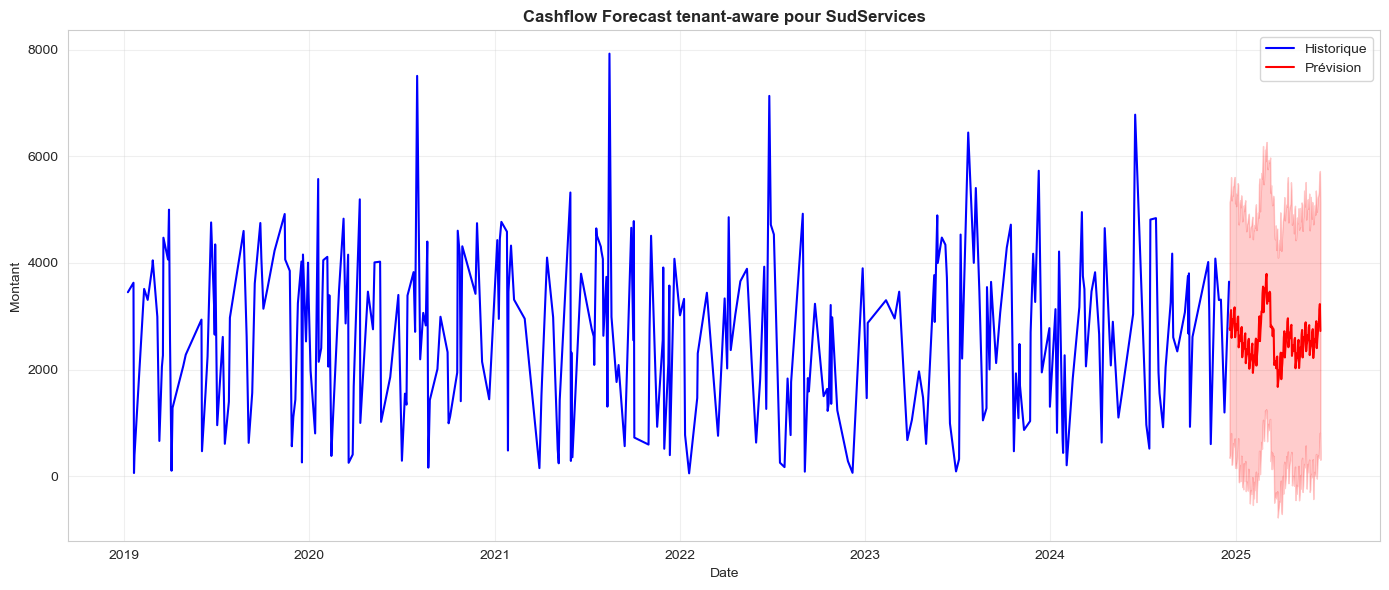

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_data['ds'], ts_data['y'], label='Historique', color='blue')
ax.plot(forecast_future['ds'], forecast_future['yhat'], label='Prévision', color='red')
ax.fill_between(forecast_future['ds'], forecast_future['yhat_lower'], forecast_future['yhat_upper'], alpha=0.2, color='red')
ax.set_title(f'Cashflow Forecast tenant-aware pour {selected_tenant}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Montant')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ⚠️ USE CASE 4: ANOMALY DETECTION

Détection d’anomalies sur les données prétraitées tenant-aware.


In [13]:
print('====================================================================================================')
print('⚠️ Anomaly Detection')
print('====================================================================================================')

iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_train_processed)

anomaly_labels_test = iso.predict(X_test_processed)
anomaly_scores_test = iso.score_samples(X_test_processed)

n_anomalies = int((anomaly_labels_test == -1).sum())
print(f'\n✅ Anomalies détectées dans le holdout: {n_anomalies} / {len(X_test_processed)}')
print(f'   Pourcentage: {n_anomalies / len(X_test_processed) * 100:.2f}%')


⚠️ Anomaly Detection

✅ Anomalies détectées dans le holdout: 101 / 2029
   Pourcentage: 4.98%


# 📉 USE CASE 5: PAYMENT DELAY REGRESSION

Régression du délai de paiement sans fuite, avec validation tenant-aware.


In [14]:
print('====================================================================================================')
print('📉 Payment Delay Regression')
print('====================================================================================================')

if 'delai_paiement_j' not in df.columns or not pd.api.types.is_numeric_dtype(df['delai_paiement_j']):
    raise ValueError('La colonne `delai_paiement_j` est requise pour la régression.')

y_reg = df['delai_paiement_j'].astype(float).fillna(df['delai_paiement_j'].median())

leakage_cols = {
    'retard_paiement', 'delai_paiement_j', 'description', 'description_enhanced',
    'categorie_produit', 'tenant_id', 'invoice_id', 'client_id', 'client_nom',
    'date_facture', 'date_echeance', 'statut_facture'
}
leakage_cols |= {col for col in X.columns if 'date' in col.lower() and any(tok in col.lower() for tok in ['facture', 'echeance', 'paye'])}

regression_features = [col for col in X.columns if col not in leakage_cols]
if not regression_features:
    raise ValueError('Aucune feature valide pour la régression après suppression des fuites.')

X_reg = X[regression_features].copy()
X_reg_train = X_reg.iloc[train_idx].reset_index(drop=True)
X_reg_test = X_reg.iloc[test_idx].reset_index(drop=True)
y_reg_train = y_reg.iloc[train_idx].reset_index(drop=True)
y_reg_test = y_reg.iloc[test_idx].reset_index(drop=True)

reg_numerical = X_reg.select_dtypes(include=[np.number]).columns.tolist()
reg_categorical = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), reg_numerical),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))]), reg_categorical)
])

reg_pipeline = Pipeline([('preprocessor', reg_preprocessor), ('regressor', LinearRegression())])
reg_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = reg_pipeline.predict(X_reg_test)

print(f'\n✅ Regression evaluation (tenant-aware holdout):')
print(f'   R2: {r2_score(y_reg_test, y_reg_pred):.4f}')
print(f'   RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)):.4f}')
print(f'   MAE: {mean_absolute_error(y_reg_test, y_reg_pred):.4f}')


📉 Payment Delay Regression

✅ Regression evaluation (tenant-aware holdout):
   R2: 0.3310
   RMSE: 17.5602
   MAE: 14.1156


# 🧾 USE CASE 6: EXPENSE CATEGORIZATION (NLP)

NLP sécurisé tenant-aware avec `description` brute + métadonnées neutres.


In [15]:
print('====================================================================================================')
print('🧾 Expense Categorization (NLP)')
print('====================================================================================================')

label_col = 'categorie_produit' if 'categorie_produit' in df.columns else None
if label_col is None:
    raise ValueError('La colonne `categorie_produit` est requise pour la catégorisation.')

meta_cols = [col for col in ['mode_paiement', 'ville', 'regime_tva', 'montant_bucket', 'facture_trimestre'] if col in df.columns]

def build_nlp_text(row):
    pieces = [str(row.get('description', '') or '')]
    for meta in meta_cols:
        value = row.get(meta, None)
        if pd.notna(value) and str(value).strip() != '':
            pieces.append(f'{meta}:{value}')
    return ' '.join(pieces)

df['nlp_input'] = df.apply(build_nlp_text, axis=1)
y_nlp = df[label_col].astype(str).fillna('unknown').copy()
groups_nlp = df['tenant_id'].astype(str)

print(f'\n✅ NLP categories: {y_nlp.nunique()}')
print(f'✅ NLP tenants: {groups_nlp.nunique()}')

if EMBEDDING_AVAILABLE:
    print('\n✅ Using sentence-transformers embedding model')
    embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    X_nlp = embedding_model.encode(df['nlp_input'].tolist(), show_progress_bar=False)
    embedding_mode = 'sentence-transformers'
    embedding_description = 'sentence-transformers embeddings'
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    print('\n⚠️ sentence-transformers unavailable, fallback to TF-IDF')
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words='english')
    X_nlp = tfidf.fit_transform(df['nlp_input'])
    embedding_mode = 'tfidf'
    embedding_description = 'TF-IDF fallback (recommend embeddings in production)'

gss_nlp = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_nlp, test_idx_nlp = next(gss_nlp.split(df, y_nlp, groups=groups_nlp))

X_train_nlp = X_nlp[train_idx_nlp]
X_test_nlp = X_nlp[test_idx_nlp]

y_train_nlp = y_nlp.iloc[train_idx_nlp].reset_index(drop=True)
y_test_nlp = y_nlp.iloc[test_idx_nlp].reset_index(drop=True)
groups_train_nlp = groups_nlp.iloc[train_idx_nlp].reset_index(drop=True)
groups_test_nlp = groups_nlp.iloc[test_idx_nlp].reset_index(drop=True)

assert set(groups_train_nlp).isdisjoint(set(groups_test_nlp))

print(f'\n✅ NLP tenant-aware split: {len(train_idx_nlp)} train / {len(test_idx_nlp)} test')
print(f'   Train tenants: {groups_train_nlp.nunique()}, Test tenants: {groups_test_nlp.nunique()}')

nlp_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
nlp_clf.fit(X_train_nlp, y_train_nlp)

y_pred_nlp = nlp_clf.predict(X_test_nlp)
nlp_accuracy = accuracy_score(y_test_nlp, y_pred_nlp)

print(f'\n✅ NLP mode: {embedding_mode} ({embedding_description})')
print(f'✅ Tenant-aware NLP accuracy: {nlp_accuracy:.4f}')
print('\n📋 Classification report:')
print(classification_report(y_test_nlp, y_pred_nlp, zero_division=0))


🧾 Expense Categorization (NLP)

✅ NLP categories: 10
✅ NLP tenants: 29

⚠️ sentence-transformers unavailable, fallback to TF-IDF

✅ NLP tenant-aware split: 7971 train / 2029 test
   Train tenants: 23, Test tenants: 6

✅ NLP mode: tfidf (TF-IDF fallback (recommend embeddings in production))
✅ Tenant-aware NLP accuracy: 0.0887

📋 Classification report:
               precision    recall  f1-score   support

        Audit       0.04      0.18      0.06        71
   Consulting       0.11      0.06      0.08       251
Développement       0.08      0.09      0.08       175
    Formation       0.04      0.08      0.06       111
  Hébergement       0.12      0.14      0.13       234
  Intégration       0.10      0.11      0.10       158
      Licence       0.14      0.06      0.08       314
     Logiciel       0.12      0.10      0.11       208
  Maintenance       0.08      0.11      0.10       203
      Support       0.14      0.05      0.07       304

     accuracy                           

In [16]:
print('====================================================================================================')
print('🔍 Expense Semantic Similarity')
print('====================================================================================================')

from sklearn.metrics.pairwise import cosine_similarity

if EMBEDDING_AVAILABLE:
    query_matrix = X_test_nlp
else:
    query_matrix = X_test_nlp.toarray()

similarity_matrix = cosine_similarity(query_matrix)
if similarity_matrix.shape[0] > 0:
    closest = similarity_matrix[0].argsort()[::-1][1:6]
    print('\n✅ Top 5 similar expense examples for holdout item 0:')
    for rank, idx in enumerate(closest, 1):
        print(f'   {rank}. Example {idx} — score {similarity_matrix[0, idx]:.4f}')
else:
    print('⚠️ No holdout NLP examples available for similarity search.')


🔍 Expense Semantic Similarity

✅ Top 5 similar expense examples for holdout item 0:
   1. Example 510 — score 1.0000
   2. Example 1040 — score 1.0000
   3. Example 156 — score 1.0000
   4. Example 1424 — score 1.0000
   5. Example 1673 — score 1.0000


## BUSINESS INSIGHTS & ACTIONS

Interprétation métier des résultats tenant-aware.


In [17]:
print('====================================================================================================')
print('🧠 Business Insights')
print('====================================================================================================')

print('\n💡 Payment Risk')
print('   - Déployer le score tenant-aware dans les workflows de recouvrement.')
print('   - Prioriser les factures à risque élevé pour chaque tenant.')
print('   - Contrôler le taux de faux positifs au niveau tenant.')

print('\n💡 Customer Segmentation')
print('   - Utiliser les segments par tenant pour personnaliser les offres.')
print('   - Traiter les segments `Champions` avec des incentives spécifiques.')

print('\n💡 Cashflow Forecast')
print(f'   - Démonstration réalisée sur le tenant exemple : {selected_tenant}.')
print('   - Le code reste générique pour tout tenant et peut être réutilisé pour une analyse multitenant.')
print('   - Vérifier les prévisions au niveau tenant avant intégration opérationnelle.')

print('\n💡 Anomaly Detection')
print('   - Envoyer les factures anormales à revue humaine au tenant concerné.')
print('   - Ne pas utiliser les anomalies comme base de segmentation client.')

print('\n💡 Regression')
print('   - Surveiller une erreur de prédiction réaliste sur des holdouts tenants distincts.')
print('   - Exclure toutes les colonnes de fuite dans `regression_features`.')

print('\n💡 NLP')
print('   - Le modèle utilise un fallback TF-IDF si les embeddings ne sont pas disponibles.')
print('   - En production, privilégier des embeddings multilingues pour le texte tunisien/français/arabe.')
print('   - Les performances peuvent rester limitées avec TF-IDF sur des descriptions métier courtes.')


🧠 Business Insights

💡 Payment Risk
   - Déployer le score tenant-aware dans les workflows de recouvrement.
   - Prioriser les factures à risque élevé pour chaque tenant.
   - Contrôler le taux de faux positifs au niveau tenant.

💡 Customer Segmentation
   - Utiliser les segments par tenant pour personnaliser les offres.
   - Traiter les segments `Champions` avec des incentives spécifiques.

💡 Cashflow Forecast
   - Démonstration réalisée sur le tenant exemple : SudServices.
   - Le code reste générique pour tout tenant et peut être réutilisé pour une analyse multitenant.
   - Vérifier les prévisions au niveau tenant avant intégration opérationnelle.

💡 Anomaly Detection
   - Envoyer les factures anormales à revue humaine au tenant concerné.
   - Ne pas utiliser les anomalies comme base de segmentation client.

💡 Regression
   - Surveiller une erreur de prédiction réaliste sur des holdouts tenants distincts.
   - Exclure toutes les colonnes de fuite dans `regression_features`.

💡 NLP
 

## DEPLOYMENT SUMMARY

Résumé des composants prêts pour un SaaS multitenant.


In [18]:
print('====================================================================================================')
print('✨ Deployment Summary')
print('====================================================================================================')

summary_data = {
    'Component': [
        'Payment Risk Prediction',
        'Payment Delay Regression',
        'Customer Segmentation',
        'Cashflow Forecasting',
        'Anomaly Detection',
        'Expense Categorization (NLP)'
    ],
    'Status': ['✅ Ready'] * 6,
    'Model Type': [
        'Classification',
        'Regression',
        'Clustering',
        'Time Series',
        'Outlier Detection',
        'NLP Classification'
    ],
    'Primary Model': [
        best_risk_model_name,
        'Linear Regression',
        'K-Means per tenant',
        'Prophet / Trend',
        'Isolation Forest',
        'Logistic Regression'
    ],
    'Notes': [
        'Tenant-aware models',
        'Leakage-free features',
        'Per-tenant clustering',
        f'Tenant-aware cashflow demo ({selected_tenant})',
        'Holdout anomalies',
        f'{embedding_description}'
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)


✨ Deployment Summary


,Component,Status,Model Type,Primary Model,Notes
0,Payment Risk Prediction,✅ Ready,Classification,Logistic Regression,Tenant-aware models
1,Payment Delay Regression,✅ Ready,Regression,Linear Regression,Leakage-free features
2,Customer Segmentation,✅ Ready,Clustering,K-Means per tenant,Per-tenant clustering
3,Cashflow Forecasting,✅ Ready,Time Series,Prophet / Trend,Tenant-aware cashflow demo (SudServices)
4,Anomaly Detection,✅ Ready,Outlier Detection,Isolation Forest,Holdout anomalies
5,Expense Categorization (NLP),✅ Ready,NLP Classification,Logistic Regression,TF-IDF fallback (recommend embeddings in produ...


In [19]:
print('\n\n📝 Notebook Metadata')
print('─' * 100)
print(f'   Dataset: invoices_ml (1).csv')
print(f'   Total invoices: {len(df):,}')
print(f'   Train invoices: {len(X_train):,}')
print(f'   Test invoices: {len(X_test):,}')
print(f'   Tenant groups train/test: {groups_train.nunique():,}/{groups_test.nunique():,}')
print(f'   Best risk model: {best_risk_model_name}')
print(f'   NLP mode: {embedding_mode}')
print(f'   Version: v2.0 - Multi-Tenant Ready')
print(f'   Notes: Tenant-aware splits, leakage protection, secure NLP')




📝 Notebook Metadata
────────────────────────────────────────────────────────────────────────────────────────────────────
   Dataset: invoices_ml (1).csv
   Total invoices: 10,000
   Train invoices: 7,971
   Test invoices: 2,029
   Tenant groups train/test: 23/6
   Best risk model: Logistic Regression
   NLP mode: tfidf
   Version: v2.0 - Multi-Tenant Ready
   Notes: Tenant-aware splits, leakage protection, secure NLP


## 🔒 Multi-Tenancy & Data Sovereignty

Ce notebook est conçu pour une plateforme SaaS tunisienne conforme et souveraine.

- **Isolation tenant-aware** : chaque modèle utilise `tenant_id` pour éviter tout mélange d’entreprises.
- **Séparation train/test stricte** : `GroupShuffleSplit` empêche un tenant d’apparaître à la fois en train et en test.
- **Segmentation par tenant** : K-Means appliqué tenant par tenant évite le cross-tenant leakage.
- **Aucune fuite de données** : `description_enhanced`, `categorie_produit`, identifiants et dates sensibles sont exclus des features.
- **NLP sécurisé** : description brute + métadonnées neutres seulement.
- **Conformité** : les performances sont évaluées sur des holdouts tenant-aware, garantissant un contrôle plus strict de la confidentialité.


In [ ]:
import joblib
import pickle
import os

# Créer le dossier models
os.makedirs('models', exist_ok=True)

# ================================
# Sauvegarder les 4 modèles
# ================================

# 1. Segmentation (KMeans)
joblib.dump(kmeans,      'models/kmeans_rfm.pkl')
rfm_scaler = locals().get('rfm_scaler', None)
if rfm_scaler is not None:
    joblib.dump(rfm_scaler, 'models/rfm_scaler.pkl')
    print("✅ rfm_scaler.pkl sauvegardé")
else:
    print("⚠️ Aucun scaler RFM disponible à sauvegarder")
print("✅ kmeans_rfm.pkl sauvegardé")

# 2. Anomalies (Isolation Forest)
joblib.dump(iso,          'models/isolation_forest.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
print("✅ isolation_forest.pkl sauvegardé")

# 3. Trésorerie (Prophet)
with open('models/prophet_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ prophet_model.pkl sauvegardé")

# 4. NLP Catégories
joblib.dump(nlp_clf, 'models/nlp_categories.pkl')
print("✅ nlp_categories.pkl sauvegardé")

print("\n🎉 Tous les modèles sauvegardés dans models/")


✅ rfm_scaler.pkl sauvegardé
✅ kmeans_rfm.pkl sauvegardé


NameError: name 'iso_forest' is not defined